# Plot and animate data as view from above (Condensed)

In [1]:
import sys, os, glob
import matplotlib.pyplot as plt
import json
import pandas as pd
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.dates as md
import multiprocessing
import shutil

from utilities.model_helpers import fetch_3d_data, convert_units_3d
from utilities.namelist_metadata import update_dataset_metadata
from utilities import new_fjet, new_fjet2, new_fjet3,  create_fade_cmap, set_name_tick_params
import utilities.tools as tools
import colormaps as pcmaps
from dask.diagnostics.progress import ProgressBar
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator
import matplotlib.axes as maxes
import colormaps as pcmaps


def create_new_jet3(n_colors=256, n_ice_colors=32):
    ice_colors = pcmaps.ice(np.linspace(1, 0.5, n_ice_colors))
    bk_colors  = pcmaps.BkBlAqGrYeOrReViWh200(np.linspace(0.1, 0.9, n_colors))
    transition = np.linspace(ice_colors[-1], bk_colors[0], 16)[1:-1]
    return mcolors.ListedColormap(np.vstack([ice_colors, transition, bk_colors]))

new_jet4 = create_new_jet3(1024)

new_jet3 = create_new_jet3()

# pyplot extension
def add_missing_data_patches(self, da, min_consecutive=2, add_legend=True, y_extend=[1, 1000], **patch_kw):
    """Add hatched rectangles for runs of missing data (≥ min_consecutive time steps).
    Call as ax.add_missing_data_patches(da, ...).

    Robust against extra dimensions (e.g. 'cell'): all non-time/diameter
    dims are collapsed before detecting gaps along time.
    """
    # Require a time dimension
    if 'time' not in da.dims:
        return

    # Use original diameter range for vertical extent
    if 'diameter' in da.dims:
        diam_vals = da['diameter'].values
        d0 = diam_vals[0] - y_extend[0]
        d1 = diam_vals[-1] + y_extend[1]
    else:
        d0, d1 = y_extend[0], y_extend[1]

    # Collapse all non-time/diameter dims so mask is 1D in time
    other_dims = [d for d in da.dims if d not in ('time', 'diameter')]
    if other_dims:
        da_1d = da.sum(dim=other_dims)
    else:
        da_1d = da

    time_values = da_1d['time'].values
    # Now da_1d has dims ('time', 'diameter') or just ('time',)
    if 'diameter' in da_1d.dims:
        no_data_mask = ~(da_1d.sum(dim='diameter') > 0)
    else:
        no_data_mask = ~(da_1d > 0)

    mask = np.asarray(no_data_mask).ravel()
    if not mask.any():
        return

    ti = np.where(mask)[0]
    gaps = np.diff(ti) > 1
    starts = np.concatenate(([0], np.where(gaps)[0] + 1))
    ends = np.concatenate((np.where(gaps)[0] + 1, [len(ti)]))

    # Use time_elapsed for x when present (log time axis); else date units
    use_elapsed = 'time_elapsed' in da_1d.coords
    if use_elapsed:
        x_vals = da_1d['time_elapsed'].values
    opts = dict(
        facecolor='lightgray', edgecolor='black', alpha=0.2,
        linewidth=0.2, hatch='///', zorder=1, **patch_kw)
    for s, e in zip(starts, ends):
        if e - s < min_consecutive:
            continue
        if use_elapsed:
            x0, x1 = float(x_vals[ti[s]]), float(x_vals[ti[e - 1]])
            if x0 <= 0:
                x0 = 0.01  # log axis requires positive x
            if x1 <= x0:
                x1 = x0 * 1.01
        else:
            t0, t1 = time_values[ti[s]], time_values[ti[e - 1]]
            x0, x1 = md.date2num(t0), md.date2num(t1)
        self.add_patch(plt.Rectangle((x0, d0), x1 - x0, d1 - d0, **opts))

    if add_legend:
        self.legend(
            handles=[Patch(facecolor=opts['facecolor'],
                           edgecolor=opts['edgecolor'],
                           alpha=opts['alpha'],
                           linewidth=opts['linewidth'],
                           hatch=opts['hatch'],
                           label='No data')],
            loc='upper right', framealpha=0.95,
        )

def format_xtick_labels(self, t0, t_end, major_interval=5, minor_interval=1):
    """Format x-axis as +MM minutes with fixed locators. Call as ax.format_xtick_labels(t0, t_end, ...)."""
    duration_min = (t_end - t0) / np.timedelta64(1, 'm')
    # Major ticks
    major_times = np.arange(0, duration_min + major_interval, major_interval)
    major_pos = [md.date2num(t0 + np.timedelta64(int(t), 'm')) for t in major_times]
    # Minor ticks
    minor_times = np.arange(0, duration_min + minor_interval, minor_interval)
    minor_pos = [md.date2num(t0 + np.timedelta64(int(t), 'm')) for t in minor_times]
    self.xaxis.set_major_locator(FixedLocator(major_pos))
    self.xaxis.set_minor_locator(FixedLocator(minor_pos))
    self.set_xticklabels([f'+{int(t):02d}' for t in major_times])
    self.tick_params(axis='x', which='major', direction='out', length=8, width=0.9)
    self.tick_params(axis='x', which='minor', direction='out', length=4, width=0.4)
    self.set_xlabel('time (min)')

def format_axis_ticks(self):
    """Set tick/grid style. Call as ax.format_axis_ticks()."""
    self.tick_params(which='both', direction='out', top=True, right=True, bottom=True, left=True)
    self.minorticks_on()
    self.tick_params(which='major', length=5)
    self.tick_params(which='minor', length=3)
    # self.xaxis.set_ticks_position('both')
    self.yaxis.set_ticks_position('both')
    self.grid(True, which='major', linestyle='--', linewidth='0.25', color='black', alpha=0.7, zorder=99.1)
    self.grid(True, which='minor', linestyle=':', linewidth='0.15', color='black', alpha=0.4, zorder=99.1)
    self.set_axisbelow(False)

maxes.Axes.add_missing_data_patches = add_missing_data_patches
maxes.Axes.format_xtick_labels = format_xtick_labels
maxes.Axes.format_axis_ticks = format_axis_ticks


def stack_figures(*figs, savepath=None, dpi=300, close_originals=True, constrained_layout=True):
    """Stack figures vertically (first on top). Returns combined figure. Accepts any number of figures."""
    if not figs:
        raise ValueError('At least one figure required')
    for fig in figs:
        fig.canvas.draw()
    bufs = [io.BytesIO() for _ in figs]
    for fig, buf in zip(figs, bufs):
        fig.savefig(buf, format='png', bbox_inches='tight', dpi=dpi)
        buf.seek(0)
    imgs = [plt.imread(b) for b in bufs]
    if close_originals:
        for fig in figs:
            plt.close(fig)
    hs = [img.shape[0] for img in imgs]
    ws = [img.shape[1] for img in imgs]
    w_max = max(ws)
    for i, img in enumerate(imgs):
        if ws[i] < w_max:
            pad = ((0, 0), (0, w_max - ws[i]), (0, 0)) if img.ndim == 3 else ((0, 0), (0, w_max - ws[i]))
            imgs[i] = np.pad(img, pad, mode='constant', constant_values=1)
    total_h = sum(hs)
    fig_combined = plt.figure(figsize=(w_max / dpi, total_h / dpi), dpi=dpi, constrained_layout=constrained_layout)
    y = 0
    for img, h in zip(imgs, hs):
        ax = fig_combined.add_axes([0, y / total_h, 1, h / total_h])
        ax.imshow(img)
        ax.axis('off')
        y += h
    if savepath:
        fig_combined.savefig(savepath, bbox_inches='tight', dpi=dpi)
    return fig_combined



# Shared helpers used by both plot_plume_path_sum and plot_plume_path_individual
def _plume_path_time(cfg, start_minute='30:00'):
    HH = cfg["ydate_ini"][-6:-4]
    t_lo = np.datetime64(f'2023-01-25T{HH}:{start_minute}')
    t_hi = np.datetime64(f'2023-01-25T{HH}:59:59')
    return t_lo, t_hi

def _plume_path_intervals(xl):
    if xl and np.diff(xl) < np.timedelta64(5, 'm'):
        return 1, 0.5
    return 5, 1

def _plume_path_fmt_datetime(ax, cfg, t_hi, xl, mi, Mi, ylim, grid):
    ax.format_xtick_labels(cfg['flare_start_datetime'], t_hi, major_interval=mi, minor_interval=Mi)
    ax.format_axis_ticks()
    ax.set(ylim=ylim, xlim=xl, xlabel='elapsed time / (min)', ylabel='')
    ax.set_title(rf"{cfg['resolution']} -- {cfg['ice_shape']} -- {cfg['flare_particles_emitted']}",
                fontsize=ax.title.get_fontsize() - 2, weight='normal')
    if not grid:
        ax.grid(False, which='both')

def _plume_path_fmt_log(ax, cfg, x_min, x_max, span, major_locs, ylim, grid):
    from matplotlib.ticker import FixedLocator, LogLocator, FuncFormatter
    ax.format_axis_ticks()
    ax.set(ylim=ylim, xlabel='elapsed time / (min)', ylabel='')
    # ax.set_title(rf"{cfg['resolution']} -- {cfg['ice_shape']} -- {cfg['flare_particles_emitted']}",
                # fontsize=ax.title.get_fontsize() - 2, weight='normal')
    ax.set_xscale('log')
    ax.set_xlim(x_min, x_max)
    ax.xaxis.set_major_locator(FixedLocator([v for v in major_locs if x_min <= v <= x_max]))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
    tick_fmt = lambda x, p: f'{x:.1f}'.rstrip('0').rstrip('.') if x < 1 else (f'{x:.0f}' if span <= 60 else f'{x/60:.1f}h')
    ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
    if not grid:
        ax.grid(False, which='both')

def _plume_path_diam_lines(ax, ds, x_lo, x_hi):
    for d in ds.diameter.values[[30, 50]]:
        ax.plot([x_lo, x_hi], [d, d], ls='--', lw=0.75, color='black', alpha=0.9, gapcolor='white')

def _add_mean_diameter_line(ax, data, x_coord='time', color=None):
    """Overlay mean diameter time series. color=None: white bg + black fg; else white bg + color fg (per-cell)."""
    total = data.sum(dim='diameter')
    mean_d = xr.where(total > 0, (data * data.diameter).sum(dim='diameter') / total, np.nan)
    x_vals, y_vals = data[x_coord].values, mean_d.values
    fg = color if color is not None else 'black'
    ax.plot(x_vals, y_vals, color='white', linewidth=2, linestyle='-', zorder=10)
    ax.plot(x_vals, y_vals, color=fg, linewidth=1, linestyle='-', zorder=11)

def _plume_path_annot(fig, axes, n_cols, n_rows=1):
    for i, ax in enumerate(np.atleast_1d(axes).flatten()):
        ax.text(0.02, 0.98, f'({chr(65+i)})', transform=ax.transAxes,
                ha='left', va='top', fontweight='semibold', fontsize=14)
        ax.set_ylabel("equivalent diameter / (µm)" if i % n_cols == 0 else "")
        ax.set_xlabel("elapsed time / (min)" if n_rows == 1 else "")

def _plume_path_prepare_data(ds, var, zlim, dim_slice=None, sum_cell=True):
    d = xr.where(ds[var] > zlim[0], ds[var], np.nan).chunk({'time': 4})
    if dim_slice is not None:
        d = d.isel(diameter=dim_slice)
    if sum_cell and 'cell' in d.dims:
        d = d.sum(dim='cell')
    if 'altitude' in d.dims:
        d = d.max(dim='altitude')
    return d

def _plume_path_add_time_elapsed(da, t0):
    el = (da.time.values - np.datetime64(t0)) / np.timedelta64(1, 'm')
    return da.assign_coords(time_elapsed=('time', el))

def _plume_path_log_axis_params(xl):
    t0 = xl[0]
    x_min = float((xl[0] - t0) / np.timedelta64(1, 'm'))
    x_max = float((xl[1] - t0) / np.timedelta64(1, 'm'))
    if x_min <= 0:
        x_min = .07
    span = x_max - x_min
    if span <= 10:
        major_locs = np.array([0.1, 1, 2, 5, 10])
    elif span <= 60:
        major_locs = np.array([0.1, 1, 2, 5, 10, 20, 50])
    else:
        major_locs = np.array([0.1, 1, 5, 10, 30, 60, 120])
    return t0, x_min, x_max, span, major_locs


def _plot_plume_panel(ax, ds, cfg_run, data, plot_kw, use_log, xl, variable2, zlim,
                      ylim, grid, add_mean_diameter_line, add_missing_data_patches, y_extend,
                      start_minute='30:00'):
    """Single-panel pcolormesh + optional variable2 overlay + axis formatting + optional single mean-diameter line."""
    t_lo, t_hi = _plume_path_time(cfg_run, start_minute)
    mi, Mi = _plume_path_intervals(xl)

    if use_log:
        t0, x_min, x_max, span, major_locs = _plume_path_log_axis_params(xl)
        data = _plume_path_add_time_elapsed(data, t0)
        pmesh = data.plot(ax=ax, x='time_elapsed', y='diameter', **plot_kw)
        data_plot = data
        if variable2:
            data2 = _plume_path_add_time_elapsed(_plume_path_prepare_data(ds, variable2, zlim, sum_cell=True), t0)
            pmesh = data2.plot(ax=ax, x='time_elapsed', y='diameter', **plot_kw)
            data_plot = data2
        _plume_path_diam_lines(ax, ds, x_min, x_max)
        _plume_path_fmt_log(ax, cfg_run, x_min, x_max, span, major_locs, ylim, grid)
    else:
        pmesh = data.plot(ax=ax, x='time', y='diameter', **plot_kw)
        data_plot = data
        if variable2:
            data2 = _plume_path_prepare_data(ds, variable2, zlim, sum_cell=True)
            pmesh = data2.plot(ax=ax, x='time', y='diameter', **plot_kw)
            data_plot = data2
        _plume_path_diam_lines(ax, ds, t_lo, t_hi)
        _plume_path_fmt_datetime(ax, cfg_run, t_hi, xl, mi, Mi, ylim, grid)

    if add_mean_diameter_line:
        coord = 'time_elapsed' if use_log else 'time'
        _add_mean_diameter_line(ax, data_plot, x_coord=coord)
    if add_missing_data_patches:
        ax.add_missing_data_patches(data, add_legend=False, y_extend=y_extend)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(
        lambda x, p: f'{x:.3f}'.rstrip('0').rstrip('.') if x < 1 else f'{x:.0f}'))
    return pmesh


def plot_plume_path_sum(ds_list, kind='integrated', ylim=(1, 1000), zlim=(1e-2, 1e4), variable='nf',
                        variable2=None, xlim=None, cmap=new_jet3, add_missing_data_patches=False,
                        grid=False, start_minute='30:00', x_axis='datetime', add_mean_diameter_line=False):
    """One panel per run, data summed over cells. If add_mean_diameter_line: one mean-diameter line per cell (distinct colors)."""
    cfg_l = list(cfg.values())
    ds_l = list(ds_list.values())
    use_log = x_axis == 'log'
    plot_kw = dict(yscale='log', norm=LogNorm(vmin=zlim[0], vmax=zlim[1]),
                   add_colorbar=False, cmap=cmap, alpha=0.95, extend='both')

    n_cols = min(4, len(ds_l))
    n_rows = len(ds_l) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4.5, n_rows*3.5), layout="constrained")
    axes = np.atleast_1d(axes)
    pmesh = None

    for ax, cfg_run, ds_cells in zip(axes.flatten(), cfg_l, ds_l):
        ds = ds_cells[kind]
        xl = xlim or list(_plume_path_time(cfg_run, start_minute))
        data = _plume_path_prepare_data(ds, variable, zlim, sum_cell=True)
        pmesh = _plot_plume_panel(ax, ds, cfg_run, data, plot_kw, use_log, xl, variable2, zlim,
                                  ylim, grid, add_mean_diameter_line=False, add_missing_data_patches=add_missing_data_patches,
                                  y_extend=[10, 1000], start_minute=start_minute)

        # Per-cell mean diameter lines (one line per cell, distinct colors)
        if add_mean_diameter_line and 'cell' in ds.dims:
            data_per_cell = _plume_path_prepare_data(ds, variable, zlim, sum_cell=False)
            if use_log:
                t0 = _plume_path_log_axis_params(xl)[0]
                data_per_cell = _plume_path_add_time_elapsed(data_per_cell, t0)
            n_cells = data_per_cell.cell.size
            colors = plt.cm.tab10(np.linspace(0, 1, max(n_cells, 1))[:n_cells])
            coord = 'time_elapsed' if use_log else 'time'
            for icell in range(n_cells):
                cell_data = data_per_cell.isel(cell=icell)
                _add_mean_diameter_line(ax, cell_data, x_coord=coord, color=colors[icell])

    fig.colorbar(pmesh, ax=axes, extend='both', aspect=30, pad=0.02,
                 label=rf'{kind} {variable} per bin / ({ds[variable].units})')
    _plume_path_annot(fig, axes, n_cols)
    fig.savefig(f'figures/figure1_{variable}{"_logtime" if use_log else ""}.png',
                bbox_inches='tight', dpi=300)
    return fig, axes


def plot_plume_path_individual(ds_list, kind='integrated', ylim=(1, 1000), zlim=(1e-2, 1e4), variable='nf',
                              variable2=None, xlim=None, cmap=new_jet3, add_missing_data_patches=False,
                              grid=False, start_minute='30:00', x_axis='datetime', add_mean_diameter_line=False):
    """One figure per run, one panel per cell."""
    cfg_l = list(cfg.values())
    ds_l = list(ds_list.values())
    use_log = x_axis == 'log'
    plot_kw = dict(yscale='log', norm=LogNorm(vmin=zlim[0], vmax=zlim[1]),
                   add_colorbar=False, cmap=cmap, alpha=0.9, extend='both')

    figs, axes_all = [], []
    for cfg_run, ds_cells in zip(cfg_l, ds_l):
        ds_all = ds_cells[kind]
        xl = xlim or list(_plume_path_time(cfg_run, start_minute))
        raw = xr.where(ds_all[variable] > zlim[0], ds_all[variable], np.nan)
        raw = raw.isel(diameter=slice(30, None)).chunk({'time': 4})

        n_rows, n_cols = len(ds_l), raw.cell.size
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4.5, n_rows*3.5), layout="constrained")
        axes = np.atleast_1d(axes)
        pmesh = None

        for icell, ax in enumerate(axes):
            data_cell = raw.isel(cell=icell)
            pmesh = _plot_plume_panel(ax, ds_all, cfg_run, data_cell, plot_kw, use_log, xl, variable2, zlim,
                                     ylim, grid, add_mean_diameter_line, add_missing_data_patches,
                                     y_extend=[0.001, 1000], start_minute=start_minute)

        fig.colorbar(pmesh, ax=axes, extend='both', aspect=30, pad=0.02,
                     label=rf'{kind} {variable} per bin / ({ds_all[variable].units})')
        _plume_path_annot(fig, axes, n_cols)
        fig.savefig(f'figures/figure1_{variable}_cells{"_logtime" if use_log else ""}.png',
                    bbox_inches='tight', dpi=300)
        figs.append(fig)
        axes_all.append(axes)
    return figs, axes_all


def plot_plume_path(ds_list, kind='integrated', ylim=(1, 1000), zlim=(1e-2, 1e4), variable='nf',
                    variable2=None, xlim=None, cmap=new_jet3, add_missing_data_patches=False,
                    grid=False, cells='sum', start_minute='30:00', x_axis='datetime',
                    add_mean_diameter_line=False):
    """Dispatch to sum or individual plot. cells: 'sum' or 'individual'."""
    if cells == 'sum':
        return plot_plume_path_sum(ds_list, kind=kind, ylim=ylim, zlim=zlim, variable=variable,
                                   variable2=variable2, xlim=xlim, cmap=cmap,
                                   add_missing_data_patches=add_missing_data_patches, grid=grid,
                                   start_minute=start_minute, x_axis=x_axis, add_mean_diameter_line=add_mean_diameter_line)
    return plot_plume_path_individual(ds_list, kind=kind, ylim=ylim, zlim=zlim, variable=variable,
                                     variable2=variable2, xlim=xlim, cmap=cmap,
                                     add_missing_data_patches=add_missing_data_patches, grid=grid,
                                     start_minute=start_minute, x_axis=x_axis, add_mean_diameter_line=add_mean_diameter_line)

In [2]:
idx_exp = 1
# cs_runs = [
#     ["cs-eriswil__20251125_114053", "50x40", 0, 191], # 50x40
#     ["cs-eriswil__20251129_230943", "50x40", 0, 191], # 50x40 ts 191  
#     ["cs-eriswil__20251209_001346", "200x160", 0, 191], # 200x160
# ]
cs_runs = [
    # ["cs-eriswil__20251129_230943", "50x40", 0, 191], 
    # ["cs-eriswil__20251125_114053", "50x40", 1, 191],    #C,  ccn400
    # ["cs-eriswil__20251209_001346", "200x160", 0, 191],  #C, ccn0
    # ["cs-eriswil__20251125_114053", "50x40", 0, 191],    #S, ccn0
    ["cs-eriswil__20260121_131528", "50x40", 0, 229],    #S=1, ccn400
    ["cs-eriswil__20260127_211338", "50x40", 0, 229],    #A=2, ccn400
    ["cs-eriswil__20260127_211338", "50x40", 1, 229],    #P=3, ccn400
    ["cs-eriswil__20260121_131528", "50x40", 1, 229],    #C=4, ccn400
#     ["cs-eriswil__20251209_001346", "200x160", 1, 191],  #S, ccn400
#     ["cs-eriswil__20260123_180947", "200x160", 0, 229],  #C, ccn0
#     ["cs-eriswil__20260123_180947", "200x160", 1, 229],  #C, ccn400
]

def flatten(xss):
    return [x for xs in xss for x in xs]


cs_run           = cs_runs[idx_exp][0]
cs_resolution    = cs_runs[idx_exp][1]
cs_run_idx       = cs_runs[idx_exp][2]

# Paths
model_data_root     = f'/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/'
processed_data_root = 'processed/'
png_path            = f'QL-TopView/{cs_run}/pngs/'

model_data_path  = f'{model_data_root}/RUN_ERISWILL_{cs_resolution}x100/ensemble_output/{cs_run}/'
extpar_file      = f'{model_data_root}/RUN_ERISWILL_{cs_resolution}x100/COS_in/extPar_Eriswil_{cs_resolution}.nc'





## Load data and setup

In [3]:

# Load metadata
flist_3d = sorted(glob.glob(model_data_path + '3D_??????????????.nc'))
exp_names = [f.split('/')[-1].split('_')[-1].split('.')[0] for f in flist_3d]

with open(glob.glob(model_data_path + "*.json")[0], "r") as jsonfile:
    meta = json.load(jsonfile)

flare_exp_name = [exp for exp in exp_names if meta[exp]['INPUT_ORG']['sbm_par']['lflare']][cs_run_idx]
flare_exp_nc_file = [f for f in flist_3d if flare_exp_name in f][0]
print(f"Flare run: {flare_exp_name}")

# Load and prepare 3D data
ds_3d = fetch_3d_data(flare_exp_nc_file, extpar_file, meta[flare_exp_name]['INPUT_ORG'], var_sets=['meteo', 'bulk', 'spec'], chunks={'time': 1})
ds_3d = update_dataset_metadata(ds_3d)
ds_3d = ds_3d.isel( altitude=slice(80, None))
ds_3d = convert_units_3d(ds_3d, ds_3d["rho"])


Flare run: 20260127211431


In [4]:

# Plot configuration
cfg = {
    'resolution': '400m' if '50x40' in meta[flare_exp_name]['domain'] else '100m',
    'resolution_deg': 0.004 if '50x40' in meta[flare_exp_name]['domain'] else 0.001,
    'dpi': 300,
    'pixel_size': (1920, 1080),
    'poolsize': 128,
    'plot_all_frames': True,
    
    # Coordinates
    'flare_lat': 47.07425, 
    'flare_lon': 7.90522,
    'origin_lat': 47.070522, 
    'origin_lon': 7.872991,
    'plot_xlim': (7.7671843, 7.94),
    'plot_ylim': (47.02, 47.12),
    'delta_x': float(1e3 * np.mean(np.diff(ds_3d.longitude.values)) * 111.13295254925466),  # 1 degree of longitude in km
    'delta_y': float(1e3 * np.mean(np.diff(ds_3d.latitude.values)) * 111.13295254925466),  # 1 degree of latitude in km
    'delta_t': float(np.mean(np.diff(ds_3d.time.astype('datetime64[s]')).astype(float))),
    'n_lon': ds_3d.longitude.size,
    'n_lat': ds_3d.latitude.size,
    'n_time': ds_3d.time.size,
    
    # Color limits
    'vel_lims': [-0.5, 0.5],
    'v_lims_qi': [1e-4, 1e0],
    
    # Font sizes
    'tick_size': 8,
    'axis_size': 9.5,
    'timer_size': 16.5,
}

# --------------------------------XARRAY SLICING--------------------------------
slice_reduced = {
    'latitude': slice(None, cfg['flare_lat'] + 2.*cfg['resolution_deg']), 
    'longitude': slice(None, cfg['flare_lon'] + 2.*cfg['resolution_deg']) 
}
ds_reduced = ds_3d.sel(**slice_reduced)


gridcell_fact = ds_reduced['rho']*cfg['delta_x']*cfg['delta_y']
ds_reduced['u'] = ds_reduced['ut'] / gridcell_fact
ds_reduced['v'] = ds_reduced['vt'] / gridcell_fact
ds_reduced['w'] = ds_reduced['wt'] / gridcell_fact
ds_reduced['qiqs'] = ds_reduced['qi'] + ds_reduced['qs']



# Load external data
slice_reduced = {
    'rlat': slice(None, cfg['flare_lat'] + 2.*cfg['resolution_deg']), 
    'rlon': slice(None, cfg['flare_lon'] + 2.*cfg['resolution_deg']) 
}
data_extpar = xr.open_mfdataset(extpar_file, chunks='auto')
data_extpar = data_extpar.sel(**slice_reduced)
lat2D  = data_extpar['lat'].values
lon2D  = data_extpar['lon'].values
height = data_extpar['HSURF'].values


In [5]:
# precip_lat = 47.047
# precip_lon = 7.845

# with ProgressBar() as pbar:
#     ds_quiver = ds_reduced[['u', 'v', 'w', 'qiqs']]
#     ds_quiver = ds_quiver.sel(time=slice(np.datetime64('2023-01-25T12:40:00'), np.datetime64('2023-01-25T13:00:00'), 3))
#     ds_quiver = ds_quiver.mean(['time', 'altitude'])
#     ds_quiver = ds_quiver.persist()

# print(f'ds_quiver.sizes:     {ds_quiver.sizes}')
# print(f'ds_quiver.data_vars: {ds_quiver.data_vars}')
# print(f'ds_quiver.u.min/max: {ds_quiver.u.min().values:.2f}, {ds_quiver.u.max().values:.2f} / (m/s)')
# print(f'ds_quiver.v.min/max: {ds_quiver.v.min().values:.2f}, {ds_quiver.v.max().values:.2f} / (m/s)')
# print(f'ds_quiver.w.min/max: {ds_quiver.w.min().values:.2f}, {ds_quiver.w.max().values:.2f} / (m/s)')

In [6]:
# def add_annotations(ax, cfg):
#     from utilities import add_ruler
#     """Add scatter points, ruler, and seeding paths."""
#     # Scatter points
#     ax.scatter(cfg['origin_lon'], cfg['origin_lat'], s=70, marker='x', color='red', zorder=2)
#     ax.scatter(cfg['flare_lon'],  cfg['flare_lat'],  s=50, marker='o', facecolor='none', edgecolor='white', linewidth=2.5, zorder=2)
#     ax.scatter(cfg['flare_lon'],  cfg['flare_lat'],  s=50, marker='o', facecolor='none', edgecolor='red', linewidth=1.0, zorder=2)
    
#     # Ruler
#     add_ruler(ax, 47.05, 7.804, cfg['flare_lat'], cfg['flare_lon'])
    
#     # Seeding paths
#     seeding_coords = { 'royalblue': ([7.90476, 7.90568], [47.07602, 47.07248]),
#                         'orange':   ([7.89828, 7.89919], [47.07526, 47.07172]),
#                         'green':    ([7.91125, 7.91216], [47.07676, 47.07322]), }
    
#     for color, (lon, lat) in seeding_coords.items():
#         dx, dy = np.diff(lon)[0], np.diff(lat)[0]
#         extended_lon = [lon[0] - dx, lon[1] + dx]
#         extended_lat = [lat[0] - dy, lat[1] + dy]
        
#         ax.plot(lon, lat, color='black', linewidth=0.9)
#         ax.plot(extended_lon, extended_lat, color='black', alpha=0.4, linewidth=0.6)
#         ax.scatter(lon, lat, color='black', marker='.', s=15)

# # --------------------------------QUICKLOOKS--------------------------------
# # test quiver plots
# fig_barb, ax_barb = plt.subplots(1, 1, figsize=(9, 5))
# add_annotations(ax_barb, cfg)
# # Create base layers
# pm_surf = ax_barb.pcolormesh(lon2D, lat2D, height, cmap='terrain', vmin=300, alpha=0.6, zorder=1)
# ( ds_quiver ).plot.quiver(ax=ax_barb, y='latitude', x='longitude', u='u', v='v', cmap='coolwarm', robust=True, scale=15, alpha=0.5)


In [7]:
# load meteogram like output

coords_precip  = (47.047, 7.845)
coords_eriswil = (47.070522, 7.872991)
coords_flare   = (47.07425, 7.90522)

coord_selection = {'latitude': [47.07425, 47.070522, 47.047],
                   'longitude': [7.90522, 7.872991, 7.845],}
coord_selection_names = ['seeding', 'eriswil', 'precip']

#time_precip = [np.datetime64('2023-01-25T12:30:00'), np.datetime64('2023-01-25T13:00:00')]

ds_meteos = ds_reduced.sel(coord_selection, method='nearest')
# ds_meteos = ds_meteos.sel(time=slice(time_precip[0], time_precip[1], 1))

ds_meteos['qiqs'] = ds_meteos['qs']+ds_meteos['qi']
ds_meteos['qiqs'].attrs['name'] = 'qi+qs'
ds_meteos['qiqs'] = xr.where(ds_meteos['qiqs']> 1e-10, ds_meteos['qiqs'], np.nan)
with ProgressBar() as pbar:
    ds_meteos = ds_meteos.persist()


[########################################] | 100% Completed | 389.04 s


In [8]:
qfw = ds_meteos.isel(time=slice(None, None, 5))
dqfw = qfw.diff('time')

X, Y   = np.meshgrid(qfw['time'].values, qfw['altitude'].values)
dX, dY = np.meshgrid(dqfw['time'].values, dqfw['altitude'].values)

U = qfw['u'].T
V = qfw['v'].T
W = qfw['w'].T
qv = qfw['qv'].T
qi = qfw['qi'].T
qs = qfw['qs'].T
qc = qfw['qc'].T
qiqs = xr.where(qi + qs > 1e-10, qi + qs, np.nan)
qiqs.attrs['name'] ='qi+qs'

dU = dqfw['u'].T
dV = dqfw['v'].T
dW = dqfw['w'].T

qfw['dw'] = dqfw['w']

In [9]:
from utilities import calculate_supersaturation_ice, calculate_supersaturation_water
ds_meteos['S_ice']   = calculate_supersaturation_ice(ds_meteos['t'], ds_meteos['qv'] / 1000 )
ds_meteos['S_water'] = calculate_supersaturation_water(ds_meteos['t'], ds_meteos['qv'] / 1000 )




The formula computes a percentage (%):
$$S = \left(\frac{e}{e_{\mathrm{sat}}} - 1\right) \times 100$$
where:
$e$ is the actual vapor pressure (Pa)
$e_{\mathrm{sat}}$ is the saturation vapor pressure (Pa)
Interpretation:
$S = 0\%$ → saturated (RH = 100%)
$S > 0\%$ → supersaturated (e.g., $S = 5\%$ means 5% above saturation)
$S < 0\%$ → subsaturated (e.g., $S = -20\%$ corresponds to RH = 80%)


In [10]:
ds_meteos['cdnc'].attrs['units'] = 'cm⁻³'
ds_meteos['icnc'].attrs['units'] = 'L⁻¹'
ds_meteos['cdnc'].attrs['standard_name'] = 'CDNC'
ds_meteos['cdnc'].attrs['long_name'] = 'Cloud droplet number concentration'
ds_meteos['icnc'].attrs['standard_name'] = 'ICNC'
ds_meteos['icnc'].attrs['long_name'] = 'Ice crystal number concentration'
ds_meteos['S_water'].attrs['units'] = '%'
ds_meteos['S_ice'].attrs['units'] = '%'
ds_meteos['S_water'].attrs['standard_name'] = 'S_water'
ds_meteos['S_water'].attrs['long_name'] = 'Supersaturation over water'
ds_meteos['S_ice'].attrs['standard_name'] = 'S_ice'
ds_meteos['S_ice'].attrs['long_name'] = 'Supersaturation over ice'

In [11]:
ds_meteos['icnc']

<xarray.DataArray 'icnc' (time: 229, altitude: 20, latitude: 3, longitude: 3)> Size: 330kB
dask.array<getitem, shape=(229, 20, 3, 3), dtype=float64, chunksize=(1, 20, 3, 3), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 2kB 2023-01-25T12:28:50 ... 2023-01-25...
  * altitude     (altitude) float64 160B 1.507e+03 1.444e+03 ... 822.0 812.8
  * latitude     (latitude) float32 12B 47.07 47.07 47.05
  * longitude    (longitude) float32 12B 7.902 7.873 7.844
    latitude2D   (latitude, longitude) float32 36B 47.07 47.07 ... 47.05 47.05
    longitude2D  (latitude, longitude) float32 36B 7.902 7.873 ... 7.873 7.844
    altitude3D   (altitude, latitude, longitude) float64 1kB dask.array<chunksize=(20, 3, 3), meta=np.ndarray>
Attributes:
    long_name:      Ice crystal number concentration
    units:          L⁻¹
    standard_name:  ICNC

In [12]:
# test bulk vars


def plot_meteogram(ds_in, wind, ilat, ilon):
    fig, ax = plt.subplots(4, 2, figsize=(12,12), constrained_layout=True)
    ds_ = ds_in.isel(latitude=ilat, longitude=ilon)

    ds_['w'].plot(  x='time', alpha=0.9, cmap=pcmaps.BlRe, vmin=-0.05, vmax=0.05, ax=ax.flat[0], )
    ds_['qc'].plot( x='time', alpha=0.9, cmap=new_fjet2,  robust=True, ax=ax.flat[2])
    ds_['qi'].plot( x='time', alpha=0.9, cmap=new_fjet2,  robust=True, ax=ax.flat[1], )
    ds_['qs'].plot( x='time', alpha=0.9, cmap=new_fjet2,  robust=True, ax=ax.flat[3])

    ds_['cdnc'].plot(   x='time', alpha=0.9, cmap=new_fjet2,  robust=True, ax=ax.flat[4])
    ds_['icnc'].plot(   x='time', alpha=0.9, cmap=new_fjet2,  robust=True, ax=ax.flat[5])
    ds_['S_ice'].plot(  x='time', alpha=0.9, cmap=pcmaps.BlRe, vmin=-5, vmax=5, ax=ax.flat[6])
    ds_['S_water'].plot(x='time', alpha=0.9, cmap=pcmaps.BlRe, vmin=-5, vmax=5, ax=ax.flat[7])

    # Matplotlib quiver: meshgrid for x=time, y=altitude; u,v,w from dqfw (dims time, altitude)

    for i, a in enumerate(ax.flatten()):
        qiv_ = wind.isel(latitude=ilat, longitude=ilon).plot.quiver(ax=a, y='altitude', x='time', u='dw', v='w', hue='w', 
                        vmin=-0.05, vmax=0.05, scale=3, cmap=pcmaps.BlRe, cbar_ax=None,
                        alpha=1., edgecolor='white', linewidth=0.2 )
        qiv_.colorbar.remove()

        a.set(xlabel="", ylabel="", title="")
        a.format_xtick_labels(ds_.time.values[0], ds_.time.values[-1], major_interval=5, minor_interval=1)
        a.format_axis_ticks()
        
    # for cax in fig.axes:
    #     if cax not in ax.flat and 'qiqs' not in cax.get_ylabel():
    #         cax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.4f}'))
    a.set_xlabel("time / (UTC)")
    return fig, ax




png saved to /home/b/b382237/code/jupyterhub_nbs/figures/figure3_precip.png


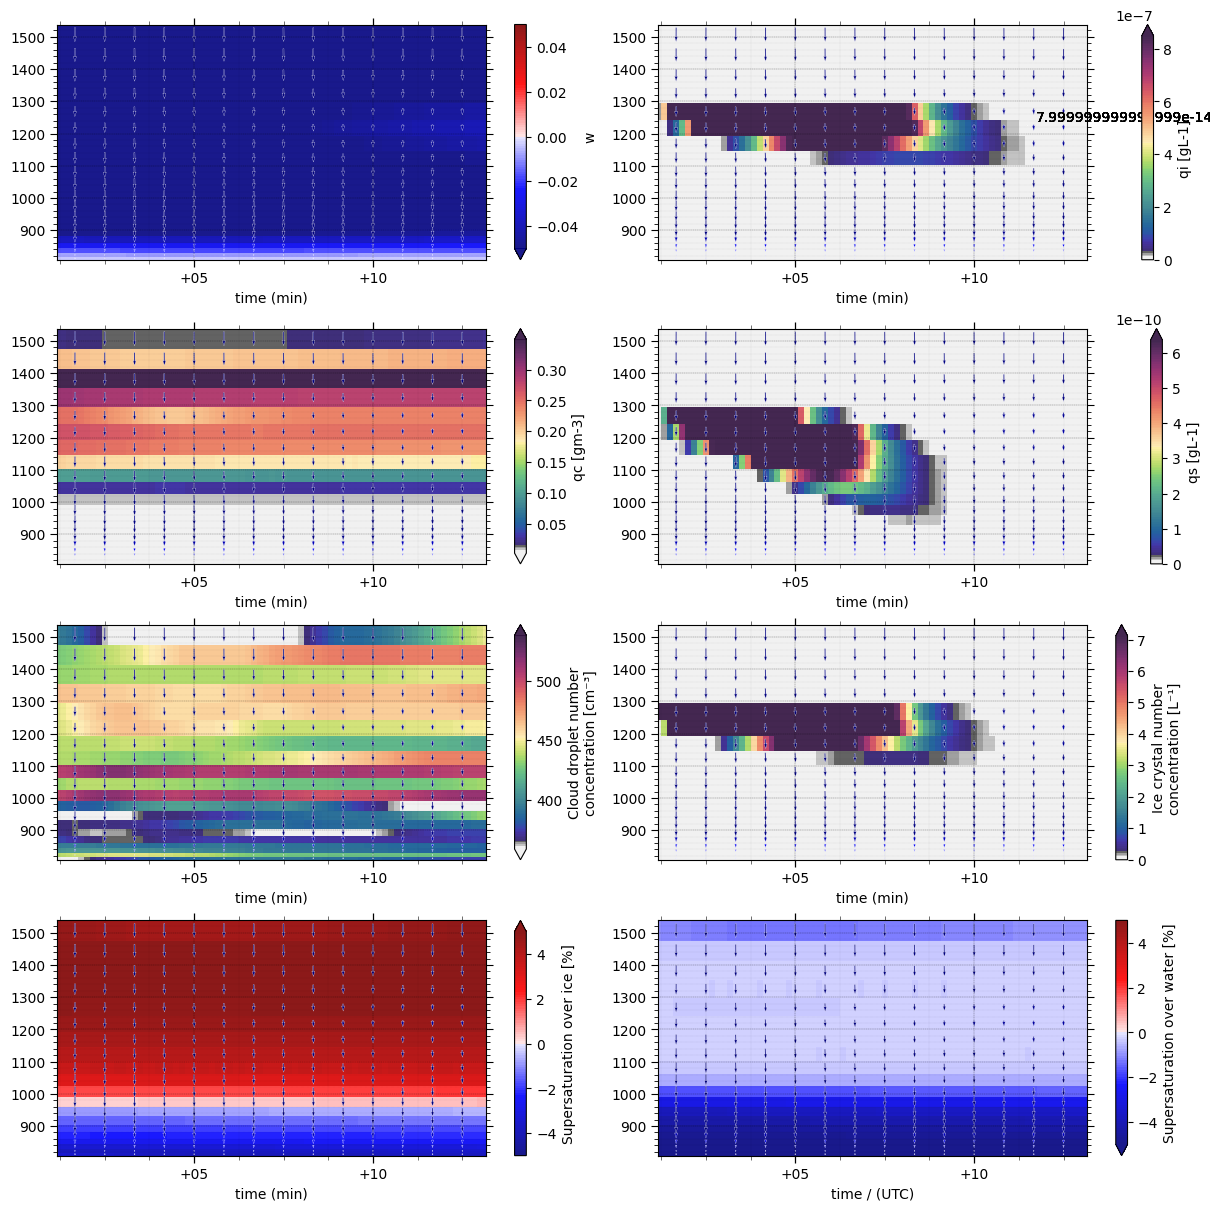

In [13]:
xlim = [np.datetime64('2023-01-25T12:30:00'), np.datetime64('2023-01-25T12:42:00')]

fig, ax = plot_meteogram(ds_meteos, qfw, 0, 0)
for a in ax.flatten():
    a.set_xlim(xlim)
fig.savefig('figures/figure3_precip.png', dpi=400, bbox_inches='tight')
print(f'png saved to {os.path.abspath("figures/figure3_precip.png")}')



png saved to /home/b/b382237/code/jupyterhub_nbs/figures/figure3_eriswil.png


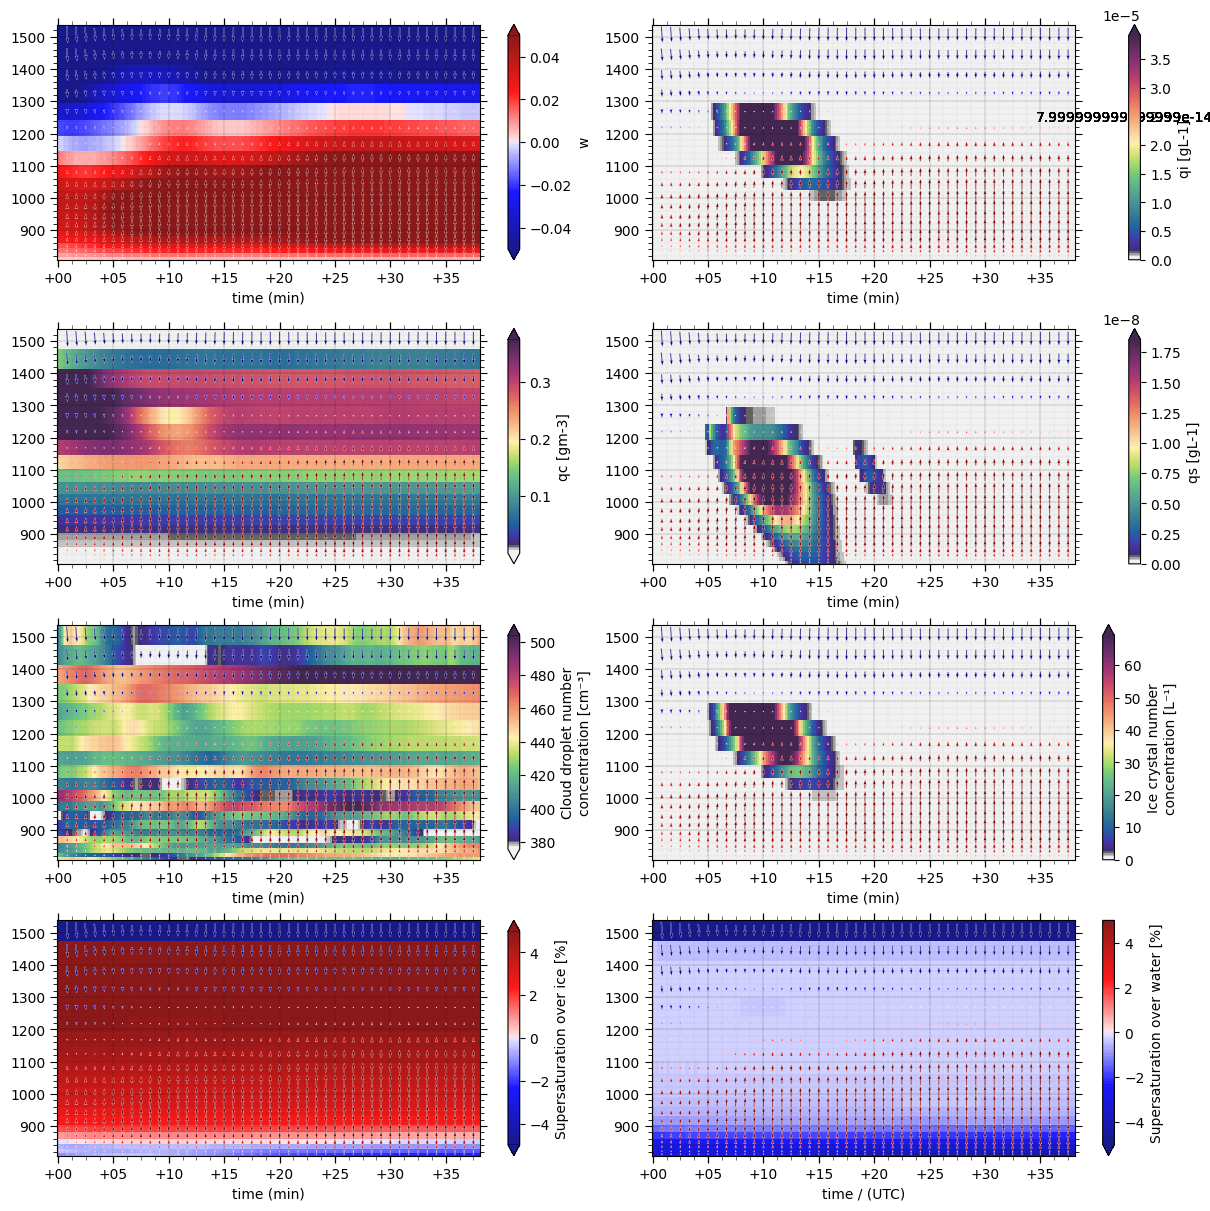

In [14]:


fig, ax = plot_meteogram(ds_meteos, qfw, 1, 1)
fig.savefig('figures/figure3_eriswil.png', dpi=400, bbox_inches='tight')
print(f'png saved to {os.path.abspath("figures/figure3_eriswil.png")}')


png saved to /home/b/b382237/code/jupyterhub_nbs/figures/figure3_flare.png


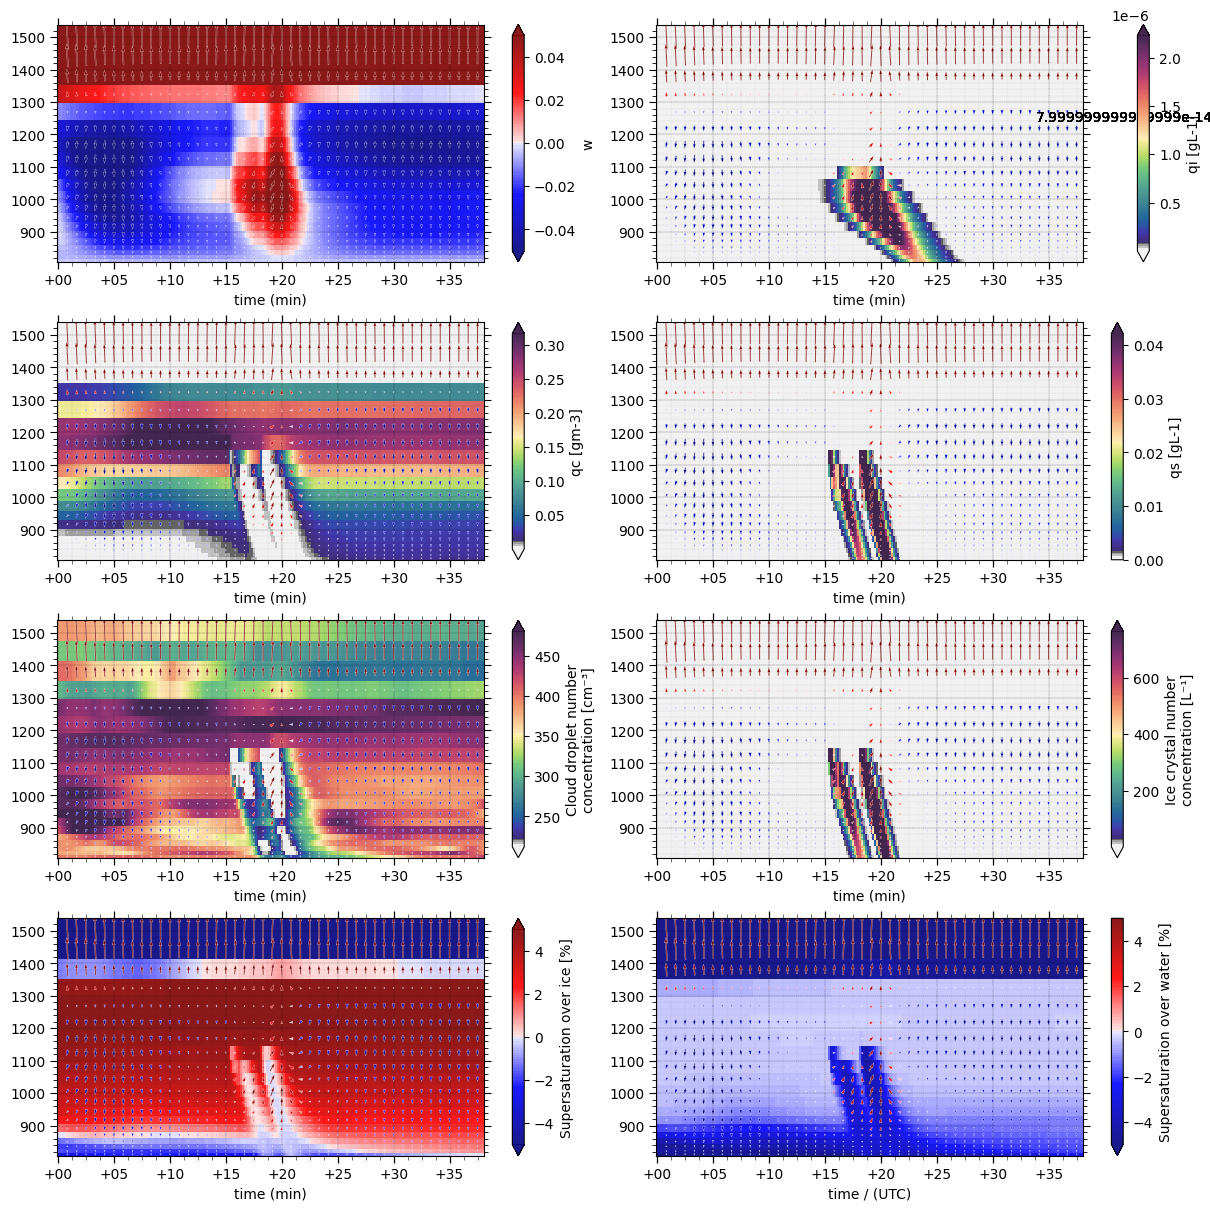

In [15]:

fig, ax = plot_meteogram(ds_meteos, qfw, 2, 2)
fig.savefig('figures/figure3_flare.png', dpi=400, bbox_inches='tight')
print(f'png saved to {os.path.abspath("figures/figure3_flare.png")}')

png saved to /home/b/b382237/code/jupyterhub_nbs/figures/figure3_flare.png


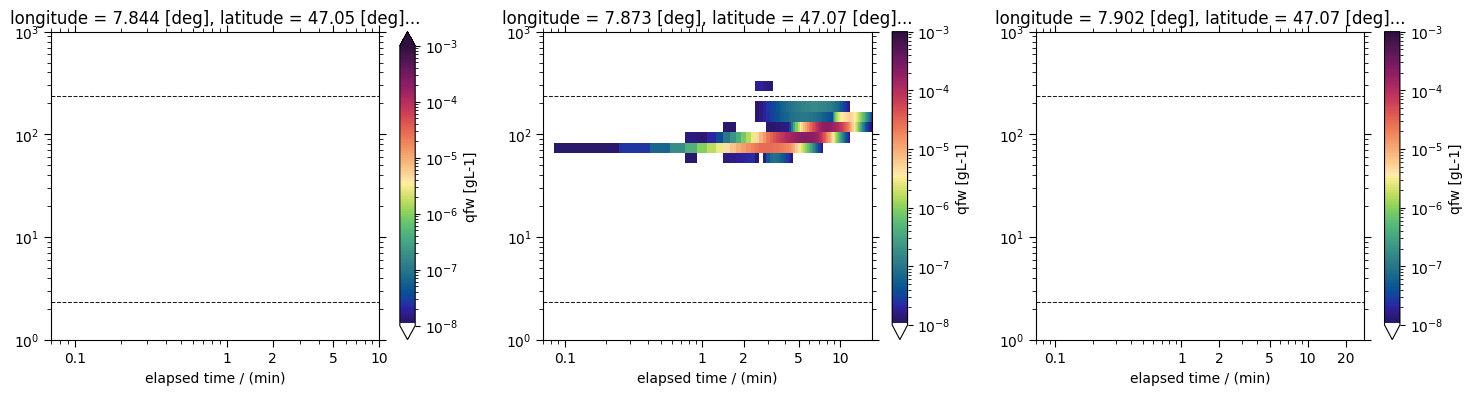

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

xl0 = [np.datetime64('2023-01-25T12:30:00'), np.datetime64('2023-01-25T12:40:00')]
xl1 = [np.datetime64('2023-01-25T12:33:00'), np.datetime64('2023-01-25T12:50:00')]
xl2 = [np.datetime64('2023-01-25T12:42:00'), np.datetime64('2023-01-25T13:10:00')]
yl = [1e0, 1e3]
for i, xl in enumerate([xl0, xl1, xl2]):
    ds_ = ds_meteos.isel(latitude=2-i, longitude=2-i).sum('altitude')
    t0, x_min, x_max, span, major_locs = _plume_path_log_axis_params(xl)
    ds_ = _plume_path_add_time_elapsed(ds_, t0)
    pmesh = ds_['qfw'].plot(ax=ax[i], x='time_elapsed', y='diameter', yscale='log', cmap=new_fjet, norm=LogNorm(vmin=1e-8, vmax=1e-3))
    
    _plume_path_diam_lines(ax[i], ds_, x_min, x_max)
    _plume_path_fmt_log(ax[i], cfg, x_min, x_max, span, major_locs, yl, grid=False)
    if i < 2:
        ax[i].set_ylabel("")



fig.savefig('figures/figure3_flare.png', dpi=400, bbox_inches='tight')
print(f'png saved to {os.path.abspath("figures/figure3_flare.png")}')

In [17]:
ds_

<xarray.Dataset> Size: 667kB
Dimensions:       (time: 229, diameter: 66)
Coordinates:
  * time          (time) datetime64[ns] 2kB 2023-01-25T12:28:50 ... 2023-01-2...
  * diameter      (diameter) float64 528B 0.00226 0.002847 ... 7.523e+03
    longitude     float32 4B 7.902
    latitude      float32 4B 47.07
    latitude2D    float32 4B 47.07
    longitude2D   float32 4B 7.902
    time_elapsed  (time) float64 2kB -13.17 -13.0 -12.83 ... 24.5 24.67 24.83
Data variables: (12/37)
    t             (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    p0            (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    pp            (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    qv            (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    rho0          (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    rho           (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    ...            ...
    u             (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    v             (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    w             (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    qiqs          (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    S_ice         (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    S_water       (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    ncfile:   /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs//...
    run_id:   20260127211431

TypeError: Axes.hist() got multiple values for argument 'x'

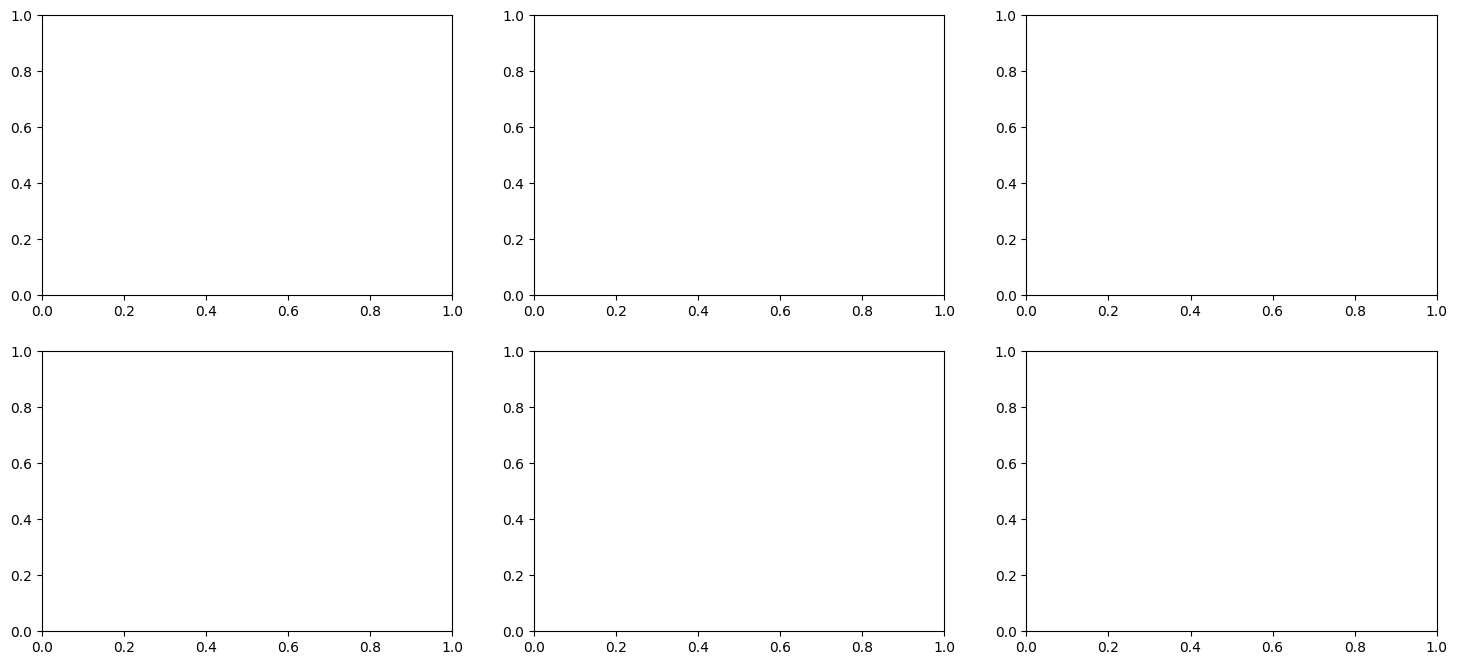

In [18]:
# test time 
n_rows = 2
n_cols = 3
fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, 8),)

dqfw['w'].plot(x='time', cmap='coolwarm',  robust=True, ax=ax.flat[0], alpha=0.85, zorder=1)
dqfw['qv'].plot(x='time', cmap='coolwarm', robust=True, ax=ax.flat[1], alpha=0.85, zorder=1)
dqfw['t'] .plot(x='time', cmap='coolwarm', robust=True, ax=ax.flat[2], alpha=0.85, zorder=1)
dqfw['qc'].plot(x='time', cmap='coolwarm', robust=True, ax=ax.flat[3], alpha=0.85, zorder=1)
dqfw['qi'].plot(x='time', cmap='coolwarm', robust=True, ax=ax.flat[4], alpha=0.85, zorder=1)
dqfw['qs'].plot(x='time', cmap='coolwarm', robust=True, ax=ax.flat[5], alpha=0.85, zorder=1)

# Matplotlib quiver: meshgrid for x=time, y=altitude; u,v,w from dqfw (dims time, altitude)
X, Y = np.meshgrid(dqfw['time'].values, dqfw['altitude'].values)

for i, a in enumerate(ax.flatten()):
    a.set(xlabel="", ylabel="", title="")
    # a.quiver(X, Y, dU, dV, dW, cmap='viridis', scale=0.03, width=0.005, minshaft=2, alpha=0.95, pivot='middle', zorder=10, clim=(dc_lo, dc_hi))
    if i % n_cols == 0:
        a.set_ylabel("altitude / (m)")
    if i % n_cols > 0:
        a.set_xlabel("time / (UTC)")
    if i % n_cols > 0:
        a.set_yticklabels([])
    a.tick_params(axis='both', which='major', labelsize=10, width=3, length=5.5)
    a.tick_params(axis='both', which='minor', width=2, length=3)
    # a.set_xlim(np.datetime64('2023-01-25T12:35:00'), np.datetime64('2023-01-25T13:00:00'))

for i in range(n_cols):
    ax[-1, i].set_xlabel("time / (UTC)")

fig.tight_layout()
fig.savefig('figures/figure4.png', dpi=400, bbox_inches='tight')


TypeError: Axes.hist() got multiple values for argument 'x'

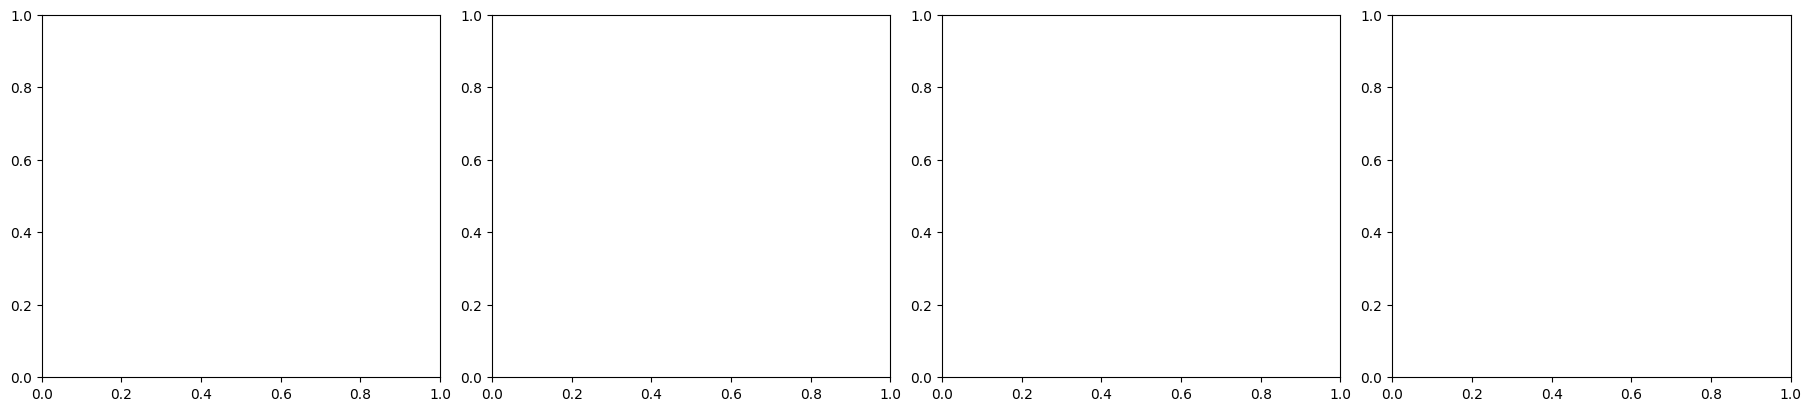

In [21]:
# test bulk vars
fig, ax = plt.subplots(1, 4, figsize=(18,4), constrained_layout=True)
ds_precip2 = ds_meteos.sel(altitude=slice(1150, 900))
ds_precip2 = ds_precip2.sum('altitude')/ds_precip2.altitude.size

ds_precip2['w'].plot(   x='time', alpha=0.9, ax=ax.flat[0], )
ds_precip2['qc'].plot(  x='time', alpha=0.9, ax=ax.flat[1])
ds_precip2['qi'].plot(  x='time', alpha=0.9, ax=ax.flat[1], )
ds_precip2['qs'].plot( x='time', alpha=0.9, ax=ax.flat[1])

ds_precip2['cdnc'].plot(x='time', alpha=0.9,  ax=ax.flat[2])
ds_precip2['icnc'].plot(x='time', alpha=0.9, ax=ax.flat[2])
ds_precip2['S_ice'].plot(x='time', alpha=0.9, ax=ax.flat[3])
ds_precip2['S_water'].plot(x='time', alpha=0.9, ax=ax.flat[3])

# Matplotlib quiver: meshgrid for x=time, y=altitude; u,v,w from dqfw (dims time, altitude)

# for i, a in enumerate(ax.flatten()):
    # qiv_xr = qfw.plot.quiver(ax=a, y='altitude', x='time', u='dw', v='w', hue='w', 
    #                 vmin=-0.05, vmax=0.05, scale=3, cmap=pcmaps.BlRe, cbar_ax=None,
    #                 alpha=1., edgecolor='white', linewidth=0.2 )
    # qiv_xr.colorbar.remove()

    # a.set(xlabel="", ylabel="", title="")
    # a.format_xtick_labels(time_precip[0], time_precip[1], major_interval=5, minor_interval=1)
    # a.format_axis_ticks()
    
# for cax in fig.axes:
#     if cax not in ax.flat and 'qiqs' not in cax.get_ylabel():
#         cax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.4f}'))
# a.set_xlabel("time / (UTC)")
fig.savefig('figures/figure3.png', dpi=400, bbox_inches='tight')
print(f'png saved to {os.path.abspath("figures/figure3.png")}')


dist_qfw.sizes: Frozen({'time': 67, 'altitude': 20, 'latitude': 3, 'longitude': 3, 'diameter': 66})


ValueError: ('altitude', 'diameter') must be a permuted list of ('altitude', 'latitude', 'longitude', 'diameter'), unless `...` is included

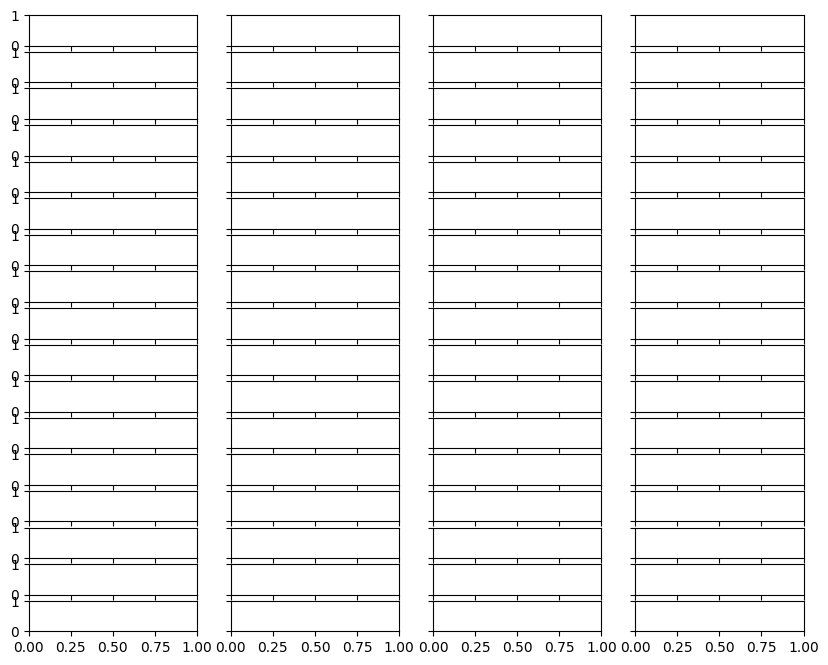

In [22]:

# test spectral vars
dist_qfw = ds_meteos[['qw', 'qfw']]
dist_qfw = dist_qfw.sel(time=slice(np.datetime64('2023-01-25T12:42:00'), np.datetime64('2023-01-25T12:53:00')))
# dist_qfw = dist_qfw.max('time')
dist_qfw = xr.where(dist_qfw < 1e-10, np.nan, dist_qfw)
print(f'dist_qfw.sizes: {dist_qfw.sizes}')

# fig, axes = plt.subplots(1,1, figsize=(7, 4),)
# ax = np.atleast_1d(axes)
g = dist_qfw['qfw'].plot.pcolormesh(
        x='diameter',      # longitude dimension
        y='altitude',       # latitude dimension
        col='time',         # create separate panels for each time step
        col_wrap=4,  # number of columns (e.g., 3 panels per row)
        figsize=(10, 8),   # adjust figure size as needed
        cmap=new_fjet,          # colormap
        sharex=True,
        sharey=True,
        xscale='log',
        xlim=[1e1, 1e3],
        add_colorbar=True,
        robust=True,      # uses 2nd and 98th percentiles for color limits
        cbar_kwargs={"orientation": "vertical",
                        "location": "right",
                        "shrink": 0.8,
                        "extend": 'both',
                    # "anchor": (0.0, 0.0, 1.0, 0.1)
                        },
        norm=LogNorm(vmin=1e-6, vmax=1e-1),
)
# dist_qfw['qw'].plot.FacetGrid(x='diameter', y='altitude', hue='time', cmap='coolwarm', col_wrap=4, xlim=[1e-2, 1e3], alpha=0.8, xscale='log', norm=LogNorm(), robust=True)
# dist_qfw['qfw'].plot.FacetGrid(x='diameter', y='altitude', hue='time', cmap='viridis', col_wrap=4, xlim=[1e-2, 1e3],  xscale='log', norm=LogNorm(), robust=True)
# g.axs.set_xlim([1e0, 1e3])
var_list = ['qw', 'qfw']


# for a, v in zip(ax.flatten(), var_list):
#     a.set_title(f"{v} / ({dist_qfw[v].attrs['units']})")
#     a.set_xlabel("diameter / (µm)")
#     a.set_ylabel("altitude / (m)")
#     a.grid(which='both', color='black', linestyle='--', linewidth=0.5, alpha=0.5)
#     a.tick_params(axis='both', which='major', labelsize=10, width=3, length=5.5)
#     a.tick_params(axis='both', which='minor', width=2, length=3)
#     # a.set_xlim(np.datetime64('2023-01-25T12:35:00'), np.datetime64('2023-01-25T13:00:00'))

# fig.suptitle("Spectral variables at strong precipitation, 47.047N, 7.845E\n diameter-height cross-sections")
# fig.savefig('figures/figure5.png', dpi=400)


/tmp/ipykernel_1468984/2350524737.py:115: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig3d.tight_layout()


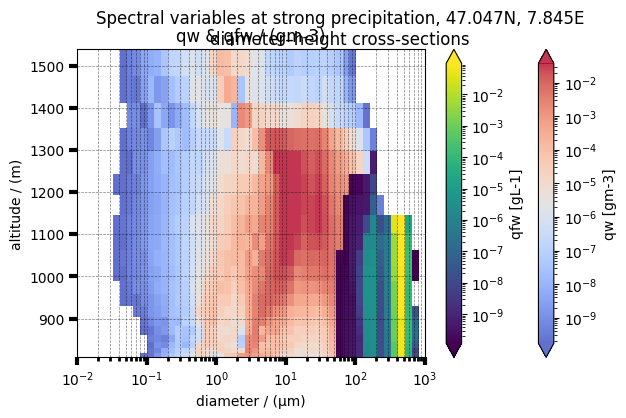

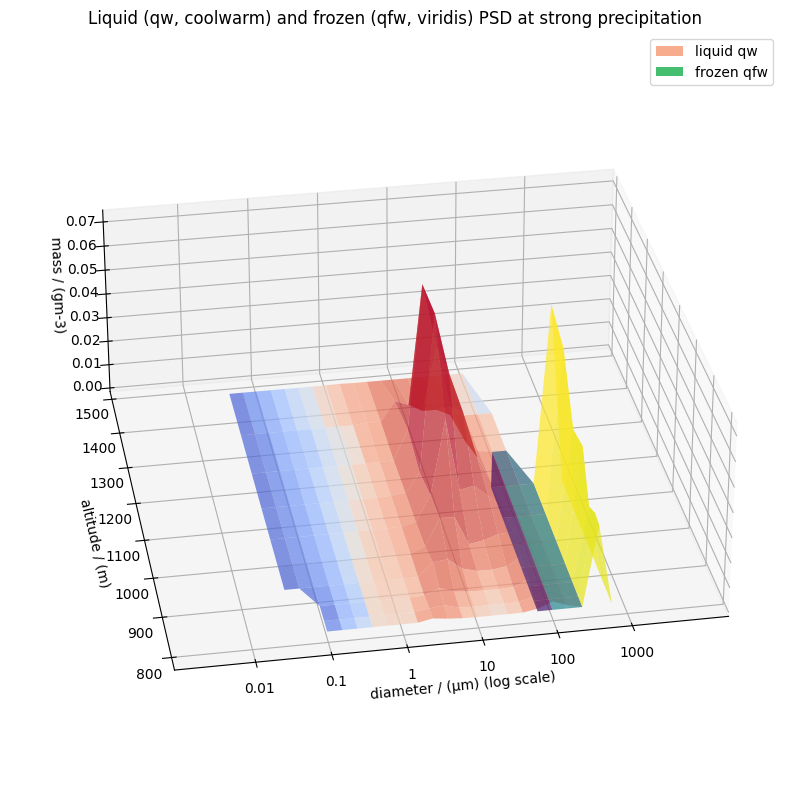

In [ ]:
# test spectral vars: 2D cross-section + 3D surfaces of liquid (qw) and frozen (qfw) PSD
dist_qfw = ds_precip[['qw', 'qfw']]
dist_qfw = dist_qfw.sel(
    time=slice(
        np.datetime64('2023-01-25T12:42:00'),
        np.datetime64('2023-01-25T12:53:00'),
    )
)
dist_qfw = dist_qfw.max('time')
dist_qfw = xr.where(dist_qfw < 1e-10, np.nan, dist_qfw)  # mask tiny values

# ----------------------------------------------------------------------
# 2D diameter–height cross-sections (as before)
# ----------------------------------------------------------------------
fig2d, axes = plt.subplots(1, 1, figsize=(7, 4))
ax2d = np.atleast_1d(axes)

dist_qfw['qw'].plot(
    x='diameter',
    cmap='coolwarm',
    xlim=[1e-2, 1e3],
    alpha=0.8,
    xscale='log',
    norm=LogNorm(),
    robust=True,
    ax=ax2d.flat[0],
)
dist_qfw['qfw'].plot(
    x='diameter',
    cmap='viridis',
    xlim=[1e-2, 1e3],
    xscale='log',
    norm=LogNorm(),
    robust=True,
    ax=ax2d.flat[0],
)

ax2d[0].set_title("qw & qfw / ({})".format(dist_qfw['qw'].attrs.get('units', '')))
ax2d[0].set_xlabel("diameter / (µm)")
ax2d[0].set_ylabel("altitude / (m)")
ax2d[0].grid(which='both', color='black', linestyle='--', linewidth=0.5, alpha=0.5)
ax2d[0].tick_params(axis='both', which='major', labelsize=10, width=3, length=5.5)
ax2d[0].tick_params(axis='both', which='minor', width=2, length=3)

fig2d.suptitle(
    "Spectral variables at strong precipitation, 47.047N, 7.845E\n"
    "diameter–height cross-sections"
)
fig2d.savefig('figures/figure5.png', dpi=400)

# ----------------------------------------------------------------------
# 3D surface plot: x=diameter (log10), y=altitude, z=mass (qw and qfw)
# ----------------------------------------------------------------------
# optionally coarsen for smoother surfaces
coarsen_factor_diam = 2   # increase to 3,4 if very dense
coarsen_factor_alt  = 2

dist_coarse = dist_qfw.coarsen(
    diameter=coarsen_factor_diam,
    altitude=coarsen_factor_alt,
    boundary='trim'
).mean()

diam = dist_coarse['diameter'].values        # physical diameter [µm]
alt = dist_coarse['altitude'].values        # altitude [m]
D, A = np.meshgrid(diam, alt)               # 2D grids

# convert diameter to log10 for plotting on a pseudo-log axis
X = np.log10(D)

qw_vals = dist_coarse['qw'].values.astype(float)
qfw_vals = dist_coarse['qfw'].values.astype(float)

fig3d = plt.figure(figsize=(14, 10))
ax3d = fig3d.add_subplot(111, projection='3d')

surf_liq = ax3d.plot_surface(
    X, A, qw_vals,
    cmap='coolwarm',
    alpha=0.7,
    edgecolor='none',
    norm=LogNorm(),
)
surf_ice = ax3d.plot_surface(
    X, A, qfw_vals,
    cmap='viridis',
    alpha=0.7,
    edgecolor='none',
    norm=LogNorm(),
)

# set x-ticks in physical diameter, but at log positions
diam_ticks = np.array([1e-2, 1e-1, 1, 1e1, 1e2, 1e3])
diam_ticks = diam_ticks[(diam_ticks >= diam.min()) & (diam_ticks <= diam.max())]

ax3d.set_xticks(np.log10(diam_ticks))
ax3d.set_xticklabels([f"{d:g}" for d in diam_ticks])
ax3d.set_xlabel("diameter / (µm) (log scale)")
ax3d.set_ylabel("altitude / (m)")
ax3d.set_zlabel(f"mass / ({dist_qfw['qw'].attrs.get('units', '')})")
ax3d.set_title("Liquid (qw, coolwarm) and frozen (qfw, viridis) PSD at strong precipitation")

from matplotlib.patches import Patch
handles = [
    Patch(facecolor=plt.cm.coolwarm(0.7), label='liquid qw'),
    Patch(facecolor=plt.cm.viridis(0.7), label='frozen qfw'),
]
ax3d.legend(handles=handles, loc='upper right')
ax3d.view_init(elev=30, azim=-100)   # more side-on
# ax3d.view_init(elev=60, azim=-120)  # more top-down
# ax3d.view_init(elev=30, azim=210)   # rotate to other side
# choose viewing angles
# ax3d.view_init(elev=30, azim=-135)  # elev: vertical, azim: horizontal rotation
ax3d.set_box_aspect((1, 1, 0.4))  # x, y, z aspect ratio
fig3d.tight_layout()
fig3d.savefig('figures/figure5_psd_3d.png', dpi=400)

In [ ]:
# # Compute column-integrated data once
# mod = ds_3d[['qi', 'qs', 'dz']].sel(  latitude=slice(None, cfg['flare_lat'] + 2.*cfg['resolution_deg']), 
#                                       longitude=slice(None, cfg['flare_lon'] + 2.*cfg['resolution_deg']) )
# mod_latlon = (mod[['qi', 'qs']] * mod['dz']).sum('altitude')

# # prepare data for tobac quicklook
# with ProgressBar() as pbar:
#     mod_latlon = xr.where(mod_latlon < 1e-7, np.nan, mod_latlon).persist()
# # plotting data
# IWC = (mod_latlon['qi'] + mod_latlon['qs']).values